#  **Contours in OpenCV**

## **1. What is `cv2.findContours()`?**

`findContours()` is a function that **detects the outlines (boundaries) of shapes/objects** in a binary image. Think of it like tracing the edge of every white blob on a black background with a pencil.

It works best on a **binary image** (black & white only), so we usually convert to grayscale and threshold the image first.

---
### **Use Cases**
- Counting objects in an image (coins, cells, etc.)
- Detecting shapes (circle, triangle, rectangle...)
- Measuring size (area, perimeter) of objects
- Isolating a document/page edge for scanning apps
- Preprocessing before OCR (isolating letters)
- Tracking a moving object's outline

---
### **Syntax**
```python
contours, hierarchy = cv2.findContours(image, mode, method)
```

### **Arguments**
| Argument | Meaning |
|---|---|
| `image` | The input **binary image** (black & white) |
| `mode` | How contours are retrieved/organized. Common options: `cv2.RETR_EXTERNAL` (outer contours only), `cv2.RETR_TREE` (all contours + hierarchy) |
| `method` | How many points are stored. `cv2.CHAIN_APPROX_SIMPLE` (compresses points, most common), `cv2.CHAIN_APPROX_NONE` (keeps all points) |

### **Returns**
- `contours` → a list of all detected shapes (each one is a set of points)
- `hierarchy` → info about which contours are inside/around others

```python
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
```

---

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\04s\s04\pic04\shapes.png", cv2.IMREAD_GRAYSCALE)
_, image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

## **2. Functions to Use *After* Finding Contours**

Once you have your `contours` list, here are the tools you'll use next 👇

---

### 🔹 `cv2.contourArea()` — Find the Area

Tells you **how many square pixels** are inside a shape.

```python
area = cv2.contourArea(contour)
```

| Argument | Meaning |
|---|---|
| `contour` | One single contour (one shape from your `contours` list) |

**Use it for:** removing tiny noisy shapes (`if area < 50: skip`), or finding the biggest object in the image.

---

In [19]:
print("Area: ", cv2.contourArea(contours[3]))

Area:  2844.0



### 🔹 `cv2.arcLength()` — Find the Perimeter

Tells you the **length of the outline** (the boundary) of a shape.

```python
perimeter = cv2.arcLength(contour, closed)
```

| Argument | Meaning |
|---|---|
| `contour` | One single contour |
| `closed` | `True` if the shape is a closed loop (most objects), `False` if it's an open curve/line |

**Use it for:** calculating perimeter, or as an input to `approxPolyDP()` below.

---

In [20]:
print("Perimeter: ", cv2.arcLength(contours[3], True))

Perimeter:  259.8233757019043


### 🔹 `cv2.boundingRect()` — Get a Bounding Box

Gives you the **smallest straight (non-tilted) rectangle** that fits around a shape.

```python
x, y, w, h = cv2.boundingRect(contour)
```

| Argument | Meaning |
|---|---|
| `contour` | One single contour |

**Returns:** `x, y` (top-left corner), `w, h` (width and height)

**Use it for:** cropping the object out of the image, or drawing a box around it.

```python
cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
```

---

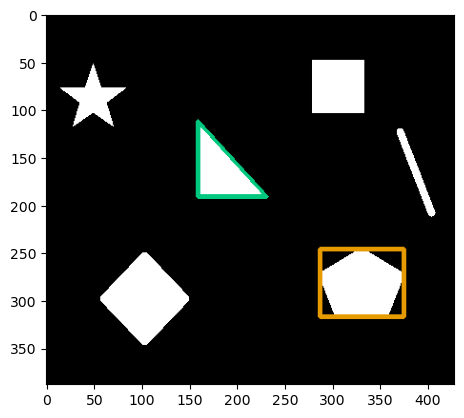

In [21]:
x, y, w, h = cv2.boundingRect(contours[1])

cv2.rectangle(bgr_image, (x, y), (x + w, y + h), (0, 156, 230), 3, lineType=cv2.LINE_8)

plt.imshow(bgr_image[..., ::-1])
plt.show()

### 🔹 `cv2.approxPolyDP()` — Simplify the Shape / Count Corners

Simplifies a bumpy contour into a **clean polygon**, so you can count how many corners it has (great for shape classification).

```python
approx = cv2.approxPolyDP(contour, epsilon, closed)
```

| Argument | Meaning |
|---|---|
| `contour` | One single contour |
| `epsilon` | How much simplification to apply — usually `0.02 * perimeter` |
| `closed` | `True` if the shape is a closed loop |

**Use it for:** shape classification —
- 3 points → Triangle
- 4 points → Square/Rectangle
- 5 points → Pentagon
- Many points → Circle

---

### 🔹 `cv2.drawContours()` — Visualize the Result

**Draws the contours** onto an image so you can see them.

```python
cv2.drawContours(image, contours, contourIdx, color, thickness)
```

| Argument | Meaning |
|---|---|
| `image` | The image you want to draw on |
| `contours` | The full list of contours |
| `contourIdx` | Which contour to draw. Use `-1` to draw **all** of them |
| `color` | BGR color tuple, e.g. `(0, 255, 0)` for green |
| `thickness` | Line thickness in pixels. Use `-1` to **fill** the shape completely |

**Use it for:** debugging (seeing what was detected), or creating a filled mask of an object.

---


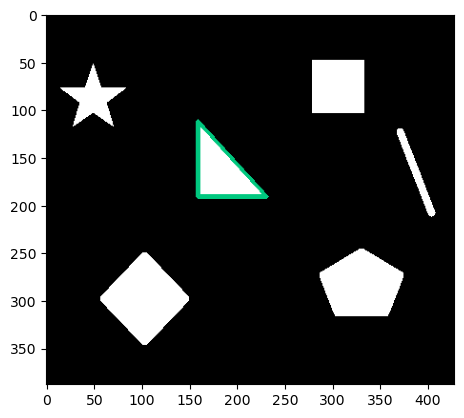

In [17]:
bgr_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
cv2.drawContours(bgr_image, contours, 3, (127, 200, 0), 4, lineType=cv2.LINE_8)
plt.imshow(bgr_image[..., ::-1])
plt.show()

## 3. Quick Alternative: `cv2.connectedComponentsWithStats()`

If you **only** need to count objects, get area, bounding box, or centroid — this is often **faster** than `findContours()` + `contourArea()`, since it labels blobs directly by pixel count instead of tracing outlines.

```python
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(image, connectivity, ltype)
```

| Argument | Meaning |
|---|---|
| `image` | Binary input image |
| `connectivity` | `4` or `8` — whether diagonal pixels count as connected |
| `ltype` | Output label datatype, usually `cv2.CV_32S` |

**Rule of thumb:**
- Just need count / area / bounding box / centroid → `connectedComponentsWithStats()`
- Need shape details (corners, perimeter, polygon approximation) → `findContours()` + the functions above